 Loaded 1674 annotations
 Filtered to 344 gaze annotations
 Computed metrics for 2 records


,session_id,child_id,session_number,phase,gaze_value,pct_session_time,mean_duration_sec,event_rate,n_events,total_time_ms,session_duration_ms
0,14_7,14,7,early,GO,95.011465,20.991885,4.807028,174,2063478,2171820
1,14_7,14,7,early,GT,10.522603,1.524538,4.309749,156,228532,2171820



Summary:
                  pct_session_time     mean_duration_sec     event_rate      \
                             mean std              mean std       mean std   
phase gaze_value                                                             
early GO                    95.01 NaN             20.99 NaN       4.81 NaN   
      GT                    10.52 NaN              1.52 NaN       4.31 NaN   

                 session_id  
                      count  
phase gaze_value             
early GO                  1  
      GT                  1  


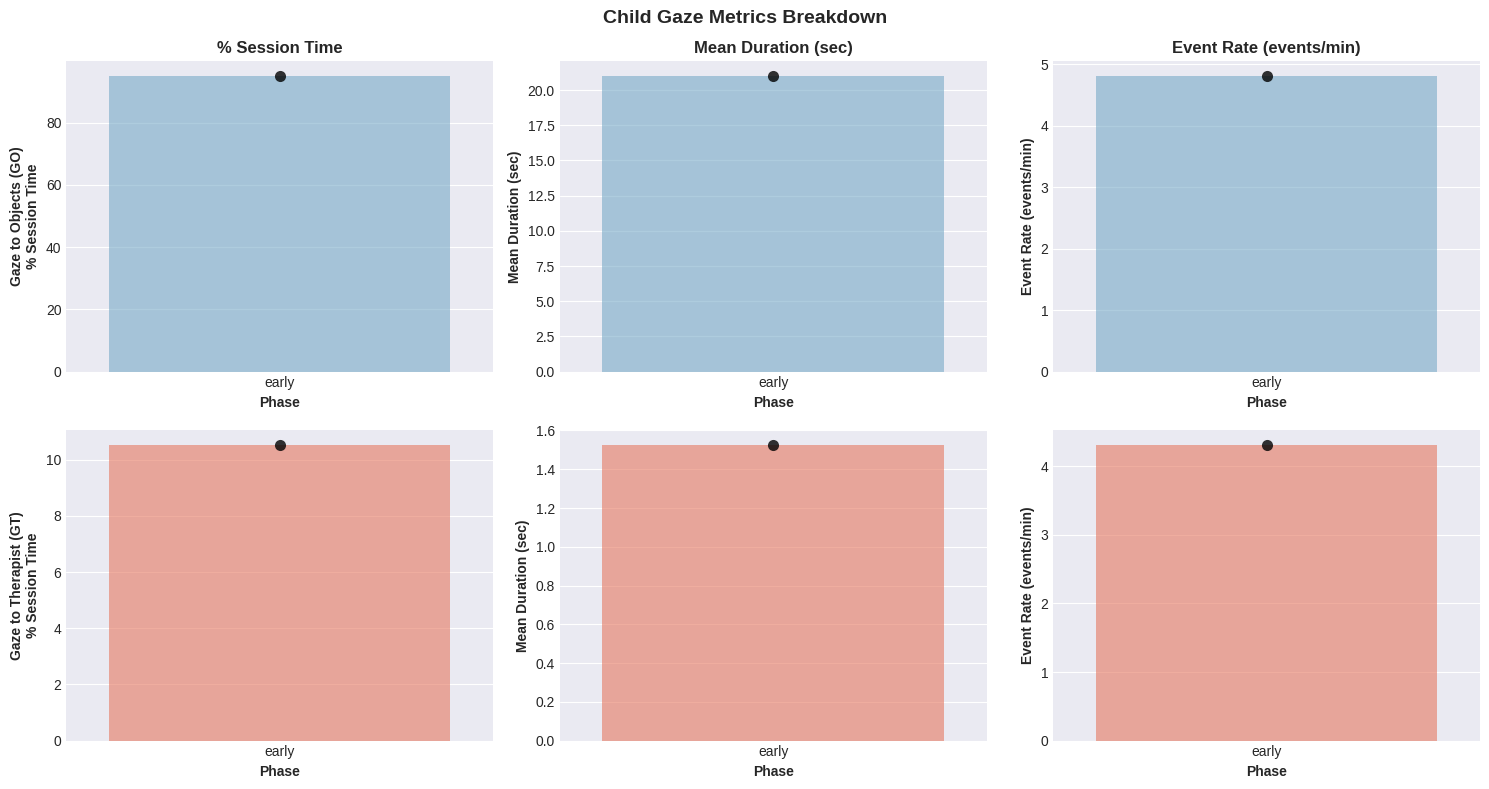

In [37]:
# %% [markdown]
# # Gaze Analysis Pipeline
# Extract gaze metrics from ELAN annotations and compare early vs late sessions.

# %% Imports & Setup
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')


# %% Configuration
GAZE_TO_OBJECTS = "GO"      # Gaze at session-related objects
GAZE_TO_THERAPIST = "GT"    # Gaze at therapist
GAZE_OTHER = ["GNO", "GU"]  # Non-session objects, undetermined

EARLY_SESSION_THRESHOLD = 10  # sessions <= 10 are "early"
LATE_SESSION_THRESHOLD = 11   # sessions >= 11 are "late"

ANNOTATIONS_CSV = "./videos/7_INDIVIDUAL_14/Annotation/annotations_master.csv"
OUTPUT_DIR = Path("./gaze_analysis_output/results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set to None to process all sessions, or specify ID e.g. "7_INDIVIDUAL_14"
SINGLE_SESSION = None

# %% Step 1 & 2: Load & Filter Data
try:
    annotations_df = pd.read_csv(ANNOTATIONS_CSV)
    print(f" Loaded {len(annotations_df)} annotations")
except FileNotFoundError:
    annotations_df = pd.DataFrame()
    print(f" File not found: {ANNOTATIONS_CSV}")

if not annotations_df.empty and "tier_code" in annotations_df.columns:
    gaze_df = annotations_df[annotations_df["tier_code"] == "CG"].copy()
    print(f" Filtered to {len(gaze_df)} gaze annotations")
    
    if SINGLE_SESSION:
        gaze_df = gaze_df[gaze_df["session_id"] == SINGLE_SESSION]
        print(f" Filtered to single session: {SINGLE_SESSION}")
else:
    gaze_df = pd.DataFrame()
    print(" Data is empty or missing 'tier_code'")

# %% Step 3: Compute Metrics per Session (With Merged Intervals & Master Duration)

def merge_intervals(df_subset):
    """Merges overlapping (start_ms_video, end_ms_video) intervals to prevent >100% session totals."""
    if df_subset.empty:
        return 0
    intervals = sorted(zip(df_subset["start_ms_video"], df_subset["end_ms_video"]))
    merged = [list(intervals[0])]
    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return sum(end - start for start, end in merged)

def compute_session_metrics(session_df, gaze_value, session_duration_ms):
    """Computes duration, event rates, and merged % session time for a given gaze code."""
    subset = session_df[session_df["value"] == gaze_value]
    
    if len(subset) == 0:
        return {
            "gaze_value": gaze_value, "pct_session_time": 0.0,
            "mean_duration_sec": 0.0, "event_rate": 0.0,
            "n_events": 0, "total_time_ms": 0
        }
    
    # Merge overlapping intervals to get true non-redundant active time
    total_time_ms = merge_intervals(subset)
    n_events = len(subset)
    mean_duration_sec = subset["duration_ms"].mean() / 1000.0 if "duration_ms" in subset.columns else 0.0
    
    # Calculate percentage based on full master video duration
    pct_session_time = (total_time_ms / session_duration_ms * 100) if session_duration_ms > 0 else 0.0
    session_duration_min = session_duration_ms / 60000.0
    event_rate = n_events / session_duration_min if session_duration_min > 0 else 0.0
    
    return {
        "gaze_value": gaze_value,
        "pct_session_time": pct_session_time,
        "mean_duration_sec": mean_duration_sec,
        "event_rate": event_rate,
        "n_events": n_events,
        "total_time_ms": total_time_ms
    }

results = []
metrics_cols = [
    "session_id", "child_id", "session_number", "phase", "gaze_value",
    "pct_session_time", "mean_duration_sec", "event_rate", "n_events",
    "total_time_ms", "session_duration_ms"
]

if not gaze_df.empty:
    for session_id in gaze_df["session_id"].unique():
        session_gaze_data = gaze_df[gaze_df["session_id"] == session_id]
        
        # 1. Fetch full session duration from master annotations_df (not filtered gaze_df)
        session_master = annotations_df[annotations_df["session_id"] == session_id] if "session_id" in annotations_df.columns else annotations_df
        session_duration_ms = session_master["end_ms_video"].max() - session_master["start_ms_video"].min()
        
        # 2. Extract child_id and session_number
        child_id = session_gaze_data["child_id"].iloc[0] if "child_id" in session_gaze_data.columns else None
        
        if "session_number" in session_gaze_data.columns:
            session_num = session_gaze_data["session_number"].iloc[0]
        else:
            match = re.search(r'(\d+)$', str(session_id))
            session_num = int(match.group(1)) if match else None
        
        # 3. Classify phase
        try:
            phase = "early" if int(session_num) <= EARLY_SESSION_THRESHOLD else "late"
        except (ValueError, TypeError):
            phase = "unknown"
        
        # 4. Compute metrics for object and therapist gaze
        for gaze_val in [GAZE_TO_OBJECTS, GAZE_TO_THERAPIST]:
            metrics = compute_session_metrics(session_gaze_data, gaze_val, session_duration_ms)
            results.append({
                "session_id": session_id,
                "child_id": child_id,
                "session_number": session_num,
                "phase": phase,
                "gaze_value": gaze_val,
                "pct_session_time": metrics["pct_session_time"],
                "mean_duration_sec": metrics["mean_duration_sec"],
                "event_rate": metrics["event_rate"],
                "n_events": metrics["n_events"],
                "total_time_ms": metrics["total_time_ms"],
                "session_duration_ms": session_duration_ms
            })

metrics_df = pd.DataFrame(results, columns=metrics_cols)

print(f" Computed metrics for {len(metrics_df)} records")
if not metrics_df.empty:
    display(metrics_df.head())

# %% Step 4: Save Metrics & Summary
if not metrics_df.empty:
    metrics_csv = OUTPUT_DIR / "gaze_metrics_per_session.csv"
    #metrics_df.to_csv(metrics_csv, index=False)
    #print(f" Saved: {metrics_csv}")
    
    summary = metrics_df.groupby(["phase", "gaze_value"]).agg({
        "pct_session_time": ["mean", "std"],
        "mean_duration_sec": ["mean", "std"],
        "event_rate": ["mean", "std"],
        "session_id": "count"
    }).round(2)
    print("\nSummary:\n", summary)

# %% Step 5 & 6: Statistical Analysis
def paired_test(early_vals, late_vals):
    if len(early_vals) == 0 or len(late_vals) == 0:
        return np.nan, np.nan, "no_data"
    if len(early_vals) < 3 or len(late_vals) < 3:
        t_stat, p_val = stats.ttest_ind(late_vals, early_vals)
        return t_stat, p_val, "ind_t_test"
        
    _, p_early = stats.shapiro(early_vals)
    _, p_late = stats.shapiro(late_vals)
    
    if (p_early >= 0.05) and (p_late >= 0.05):
        t_stat, p_val = stats.ttest_rel(late_vals, early_vals)
        return t_stat, p_val, "paired_t_test"
    else:
        w_stat, p_val = stats.wilcoxon(late_vals, early_vals)
        return w_stat, p_val, "wilcoxon"

stats_results = []
stats_cols = [
    "child_id", "gaze_value", "metric", "n_early", "n_late",
    "early_mean", "late_mean", "mean_diff", "pct_change",
    "test_name", "statistic", "p_value", "significant"
]

if not metrics_df.empty and "child_id" in metrics_df.columns:
    for child_id in metrics_df["child_id"].dropna().unique():
        child_data = metrics_df[metrics_df["child_id"] == child_id]
        for gaze_val in [GAZE_TO_OBJECTS, GAZE_TO_THERAPIST]:
            gaze_data = child_data[child_data["gaze_value"] == gaze_val]
            early_data = gaze_data[gaze_data["phase"] == "early"]
            late_data = gaze_data[gaze_data["phase"] == "late"]
            
            for metric in ["pct_session_time", "mean_duration_sec", "event_rate"]:
                early_vals = early_data[metric].values
                late_vals = late_data[metric].values
                if len(early_vals) > 0 and len(late_vals) > 0:
                    t_stat, p_val, test_name = paired_test(early_vals, late_vals)
                    mean_diff = late_vals.mean() - early_vals.mean()
                    stats_results.append({
                        "child_id": child_id, "gaze_value": gaze_val, "metric": metric,
                        "n_early": len(early_vals), "n_late": len(late_vals),
                        "early_mean": early_vals.mean(), "late_mean": late_vals.mean(),
                        "mean_diff": mean_diff,
                        "pct_change": (mean_diff / early_vals.mean() * 100) if early_vals.mean() > 0 else 0,
                        "test_name": test_name, "statistic": t_stat, "p_value": p_val,
                        "significant": "*" if (not np.isnan(p_val) and p_val < 0.05) else ""
                    })

stats_df = pd.DataFrame(stats_results, columns=stats_cols)

if not stats_df.empty:
    stats_csv = OUTPUT_DIR / "gaze_early_vs_late_stats.csv"
    #stats_df.to_csv(stats_csv, index=False)
    #print(f" Saved stats: {stats_csv}")

# %% Step 7: Visualizations (Supports Single or Multiple Phases)
if not metrics_df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Child Gaze Metrics Breakdown", fontsize=14, fontweight="bold")

    gaze_values = ["GO", "GT"]
    gaze_labels = {"GO": "Gaze to Objects (GO)", "GT": "Gaze to Therapist (GT)"}
    metric_cols = ["pct_session_time", "mean_duration_sec", "event_rate"]
    metric_labels = {
        "pct_session_time": "% Session Time",
        "mean_duration_sec": "Mean Duration (sec)",
        "event_rate": "Event Rate (events/min)"
    }

    for row, gaze_val in enumerate(gaze_values):
        data = metrics_df[metrics_df["gaze_value"] == gaze_val]
        
        for col, metric in enumerate(metric_cols):
            ax = axes[row, col]
            
            if len(data) > 0:
                # Plots bar chart for mean values + individual session data points
                sns.barplot(
                    data=data, x="phase", y=metric, ax=ax,
                    palette="Blues" if gaze_val == "GO" else "Reds",
                    capsize=0.1, errorbar="sd", alpha=0.6
                )
                sns.stripplot(
                    data=data, x="phase", y=metric, ax=ax,
                    color="black", size=8, jitter=0.1, alpha=0.8
                )
            
            ax.set_ylabel(metric_labels[metric], fontweight="bold")
            ax.set_xlabel("Phase", fontweight="bold")
            
            if row == 0:
                ax.set_title(metric_labels[metric], fontweight="bold")
            if col == 0:
                ax.set_ylabel(f"{gaze_labels[gaze_val]}\n{metric_labels[metric]}", fontweight="bold")

    plt.tight_layout()
    fig_path = OUTPUT_DIR / "figure_gaze_metrics.png"
    #plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    #print(f" Saved figure: {fig_path}")
    plt.show()
else:
    print("Skipping figure generation: metrics_df is empty.")

# %% Step 8: Export Summary Table for Paper
if not metrics_df.empty and "phase" in metrics_df.columns:
    summary_table = metrics_df.groupby(["phase", "gaze_value"]).agg({
        "pct_session_time": ["mean", "std"],
        "mean_duration_sec": ["mean", "std"],
        "event_rate": ["mean", "std"],
    }).round(2)
    summary_table.columns = ["_".join(col).strip() for col in summary_table.columns.values]
    summary_csv = OUTPUT_DIR / "gaze_summary_table.csv"
    #summary_table.to_csv(summary_csv)
    #print(f"✓ Saved summary table: {summary_csv}")
